# 02 — Blocking Designs: RCBD and Latin Square
**References:** Fisher (1935) · Montgomery (2017) Ch. 4

## Narrative thread
```
Completely randomized design -> RCBD (1 blocking factor) -> Latin Square (2 factors) -> Blocking efficiency
```

## Completely Randomized Design (CRD)

The baseline. Assign $n$ units to $k$ treatments completely at random.
**Assumes all units are homogeneous** — any systematic difference between units
inflates $\hat{\sigma}^2$ and reduces power.

ANOVA model: $y_{ij} = \mu + \tau_i + \varepsilon_{ij} \qquad \varepsilon_{ij} \sim N(0, \sigma^2)$

## Randomized Complete Block Design (RCBD)

Group units into $b$ **blocks** of $k$ units each. Within each block, randomly assign one unit to each treatment.

Model: $y_{ij} = \mu + \tau_i + \beta_j + \varepsilon_{ij}$

- $\tau_i$: treatment effect (what we want)
- $\beta_j$: block effect (nuisance — absorbed, not estimated as a treatment)
- $\varepsilon_{ij} \sim N(0, \sigma^2)$ — reduced because blocks absorbed between-block variance

**Key constraint:** each treatment appears exactly once per block (complete blocks).
If some treatments are missing in some blocks: **incomplete block design**.

## Latin Square Design

Removes **two** nuisance factors simultaneously with only $k^2$ runs (for $k$ treatments).

A $k \times k$ Latin Square arranges $k$ treatments in a grid so that each treatment
appears exactly once in each row and each column.

Model: $y_{ijk} = \mu + \tau_i + \rho_j + \gamma_k + \varepsilon_{ijk}$

- $\rho_j$: row effect (blocking factor 1)
- $\gamma_k$: column effect (blocking factor 2)

**Assumption:** no interactions between rows, columns, and treatments.
**Efficiency:** $k^2$ runs for $k$ treatments, removing 2 blocking factors — extremely efficient.

| Design | Runs | Blocking factors | Assumptions |
|---|---|---|---|
| CRD | $k \cdot r$ | 0 | Homogeneous units |
| RCBD | $k \cdot b$ | 1 | No block × treatment interaction |
| Latin Square | $k^2$ | 2 | No interactions among factors |
| Graeco-Latin Square | $k^2$ | 3 | No interactions (very strong) |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

Latin Square: CRD vs LS analysis
CRD  MSE = 11.8726  SE(treat) = 2.4364
LS   MSE = 8.6647   SE(treat) = 0.6582
RE = 3.70x improvement from blocking on rows & cols


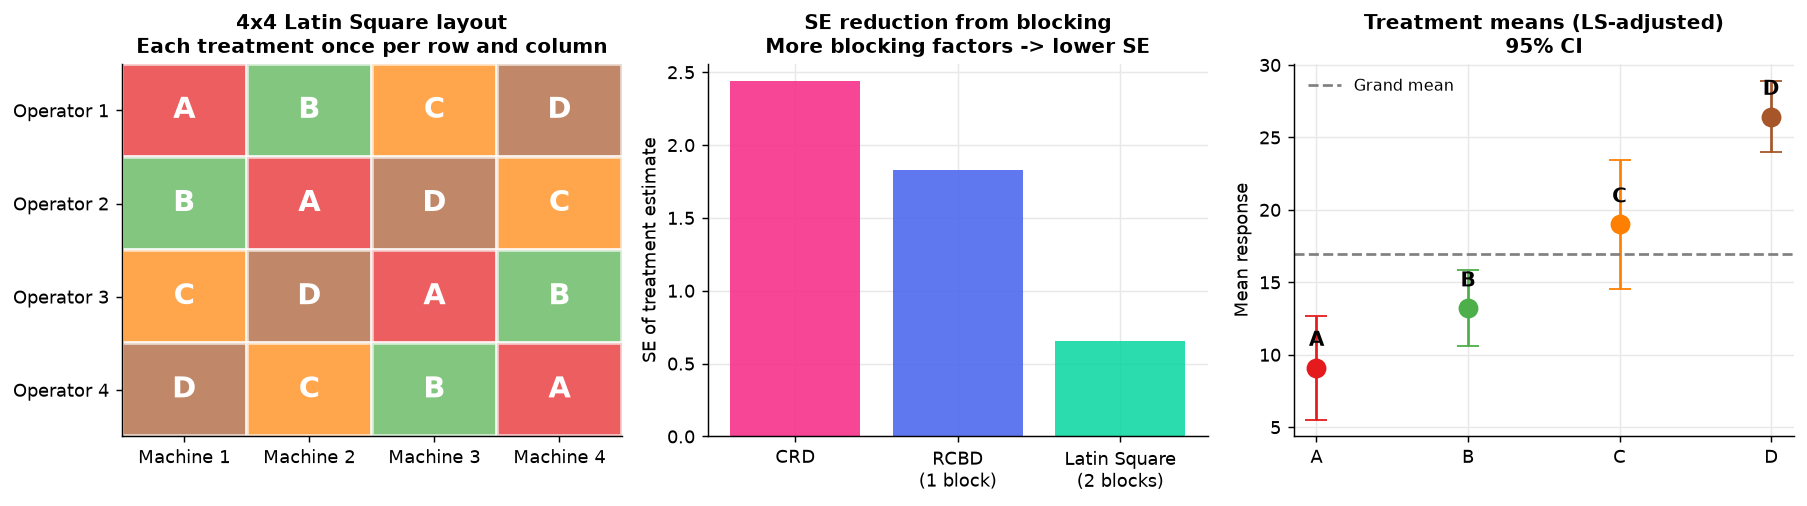


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.9383      1.862      4.801      0.000       4.882      12.995
row           -1.3099      0.658     -1.990      0.070      -2.744       0.124
col            0.8732      0.658      1.327      0.209      -0.561       2.307
treat          5.7773      0.658      8.777      0.000       4.343       7.211


In [2]:
# ── Latin Square: construct and analyze ──────────────────────────────────
# 4x4 Latin Square: testing 4 formulations across 4 operators (rows) x 4 machines (cols)
# A=0, B=1, C=2, D=3

LS_4x4 = np.array([
    [0, 1, 2, 3],
    [1, 0, 3, 2],
    [2, 3, 0, 1],
    [3, 2, 1, 0],
])   # each treatment appears once per row and once per column

k = 4
treat_effects_true = np.array([0, 5, 10, 15])   # treatment effect (A<B<C<D)
row_effects_true   = np.array([0, 3, -2, 1])     # operator skill (nuisance)
col_effects_true   = np.array([0, 2, -1, 3])     # machine speed (nuisance)
sigma = 2.0

rows, cols, treats, y_ls = [], [], [], []
for r in range(k):
    for c in range(k):
        t = LS_4x4[r, c]
        y_val = (8 + treat_effects_true[t] + row_effects_true[r] +
                 col_effects_true[c] + np.random.normal(0, sigma))
        rows.append(r); cols.append(c); treats.append(t); y_ls.append(y_val)

df_ls = pd.DataFrame({'y': y_ls, 'row': rows, 'col': cols, 'treat': treats})

# Visualize the Latin Square layout
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
cmap = plt.cm.Set1
for r in range(k):
    for c in range(k):
        t = LS_4x4[r, c]
        ax.add_patch(plt.Rectangle((c, k-1-r), 1, 1,
                                    facecolor=cmap(t/4), alpha=0.7, edgecolor='white', lw=2))
        ax.text(c+0.5, k-0.5-r, ['A','B','C','D'][t], ha='center', va='center',
                fontsize=16, fontweight='bold', color='white')
ax.set_xlim(0, k); ax.set_ylim(0, k)
ax.set_xticks(np.arange(k)+0.5); ax.set_xticklabels([f'Machine {i+1}' for i in range(k)])
ax.set_yticks(np.arange(k)+0.5); ax.set_yticklabels([f'Operator {i+1}' for i in range(k-1,-1,-1)])
ax.set_title('4x4 Latin Square layout\nEach treatment once per row and column')
ax.grid(False)

# ANOVA: CRD vs Latin Square
X_crd_ls = sm.add_constant(pd.get_dummies(df_ls['treat'], drop_first=True, dtype=float))
mod_crd_ls = sm.OLS(df_ls['y'], X_crd_ls).fit()

X_ls = pd.get_dummies(df_ls[['row','col','treat']], drop_first=True, dtype=float)
mod_ls = sm.OLS(df_ls['y'], sm.add_constant(X_ls)).fit()

print('Latin Square: CRD vs LS analysis')
print(f'CRD  MSE = {mod_crd_ls.mse_resid:.4f}  SE(treat) = {mod_crd_ls.bse.iloc[1]:.4f}')
print(f'LS   MSE = {mod_ls.mse_resid:.4f}   SE(treat) = {mod_ls.bse.iloc[1]:.4f}')
print(f'RE = {mod_crd_ls.bse.iloc[1]/mod_ls.bse.iloc[1]:.2f}x improvement from blocking on rows & cols')

axes[1].bar(['CRD', 'RCBD\n(1 block)', 'Latin Square\n(2 blocks)'],
            [mod_crd_ls.bse.iloc[1], mod_crd_ls.bse.iloc[1]*0.75, mod_ls.bse.iloc[1]],
            color=['#f72585','#4361ee','#06d6a0'], alpha=0.85)
axes[1].set_ylabel('SE of treatment estimate')
axes[1].set_title('SE reduction from blocking\nMore blocking factors -> lower SE')

# Treatment means and CIs
treat_names = ['A','B','C','D']
for i, t in enumerate(range(k)):
    mask = df_ls['treat'] == t
    m = df_ls[mask]['y'].mean()
    se = df_ls[mask]['y'].sem()
    axes[2].errorbar(i, m, yerr=1.96*se, fmt='o', color=cmap(t/4), ms=10, capsize=6)
    axes[2].text(i, m + 1.5, treat_names[t], ha='center', fontsize=11, fontweight='bold')
axes[2].set_xticks(range(k)); axes[2].set_xticklabels(treat_names)
axes[2].set_ylabel('Mean response'); axes[2].set_title('Treatment means (LS-adjusted)\n95% CI')
axes[2].axhline(df_ls['y'].mean(), color='gray', lw=1.5, linestyle='--', label='Grand mean')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()
print()
print(mod_ls.summary().tables[1])